# Phân tích sâu và Phân nhóm chỉ số Di truyền (Diabetes Pedigree Function)

Trong phần này, chúng ta sẽ đi sâu vào việc phân tích sự phân hóa của chỉ số di truyền giữa hai nhóm mắc bệnh và không mắc bệnh. Thay vì chỉ nhìn vào các con số thống kê cơ bản, Test 02 tập trung vào:

1.  **Phân tích mật độ (Density Analysis):** Sử dụng Violin Plot để thấy rõ hình dáng phân phối dữ liệu ở từng nhóm.
2.  **Kỹ thuật Phân nhóm (Binning):** Chia chỉ số Pedigree thành các mức độ Thấp, Trung bình, Cao để tính toán tỷ lệ mắc bệnh thực tế, từ đó đưa ra cái nhìn trực quan nhất về tầm quan trọng của yếu tố di truyền.
3.  **Phân phối tích lũy (CFD):** Biểu đồ CDF giúp xác định xác suất tích lũy của chỉ số Pedigree Function cho từng nhóm cho thấy rõ mức độ "lệch" của nhóm mắc bệnh so với nhóm bình thường ở mọi ngưỡng giá trị.


In [44]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"

column_names = [
    "pregnancies", "glucose", "blood_pressure", "skin_thickness", 
    "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"
]

df = pd.read_csv(data_path, header=None, names=column_names)
sns.set_theme(style="whitegrid")

df[['diabetes_pedigree_function', 'outcome']].head()

,diabetes_pedigree_function,outcome
0,0.627,1
1,0.351,0
2,0.672,1
3,0.167,0
4,2.288,1


## 1. Phân tích mật độ phân phối dữ liệu (Violin Plot)

Chúng ta sử dụng **Violin Plot** thay vì Boxplot thông thường để có cái nhìn chi tiết hơn về mật độ của `diabetes_pedigree_function`. 
*   **Độ rộng:** Đại diện cho mật độ tập trung dữ liệu tại giá trị đó.
*   **Các đường gạch ngang bên trong:** Đại diện cho các mức phân vị (Quartiles), giúp xác định xu hướng trung tâm của dữ liệu cho từng nhóm Outcome.

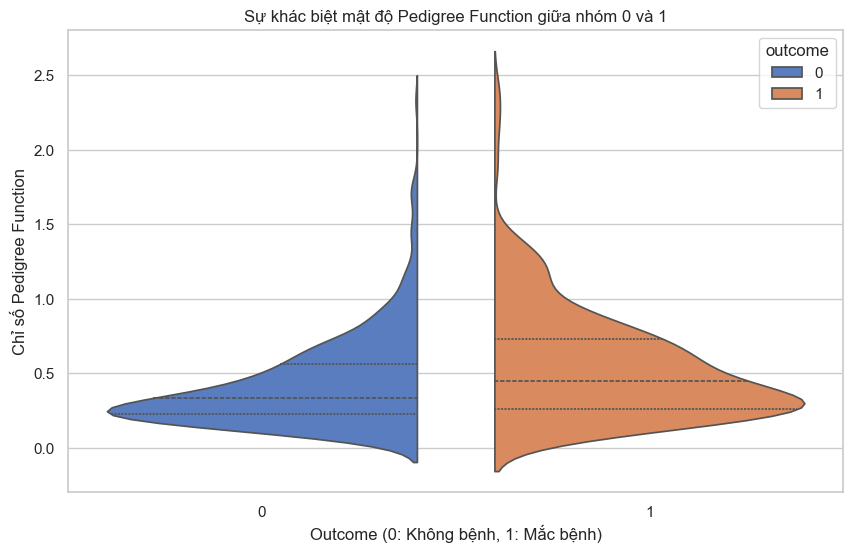

In [45]:
plt.figure(figsize=(10, 6))

# Violin plot để so sánh phân phối giữa 2 nhóm Outcome
sns.violinplot(
    data=df, 
    x="outcome", 
    y="diabetes_pedigree_function", 
    hue="outcome", 
    palette="muted", 
    inner="quartile",
    split=True
)

plt.title("Sự khác biệt mật độ Pedigree Function giữa nhóm 0 và 1")
plt.xlabel("Outcome (0: Không bệnh, 1: Mắc bệnh)")
plt.ylabel("Chỉ số Pedigree Function")
plt.show()

> **Nhận xét biểu đồ Violin:**
> *   **Nhóm Outcome 0 (Xanh):** Dữ liệu tập trung cực kỳ dày đặc ở vùng giá trị thấp (gần mức 0.2 - 0.4). Phần đuôi phía trên rất mỏng, cho thấy rất ít người không mắc bệnh có chỉ số di truyền cao.
> *   **Nhóm Outcome 1 (Cam):** Phần "thân" biểu đồ rộng hơn và kéo dài lên phía trên rõ rệt. Các đường phân vị (Quartiles) của nhóm này đều nằm ở mức cao hơn so với nhóm 0, chứng tỏ sự liên quan mật thiết giữa chỉ số di truyền cao và nguy cơ mắc bệnh.

## 2. Kỹ thuật Phân nhóm (Binning) và Tỉ lệ mắc bệnh (%)

Để làm rõ hơn sự liên quan giữa yếu tố di truyền và nguy cơ mắc bệnh, chúng ta chia biến `diabetes_pedigree_function` thành 4 nhóm dựa trên phân vị (Quartiles):
*   **Thấp:** Nhóm 25% người có chỉ số thấp nhất.
*   **Trung bình:** Nhóm từ 25% - 50%.
*   **Khá cao:** Nhóm từ 50% - 75%.
*   **Rất cao:** Nhóm 25% người có chỉ số cao nhất.

Việc này giúp chúng ta thấy được xu hướng tăng trưởng của tỉ lệ bệnh một cách trực quan.

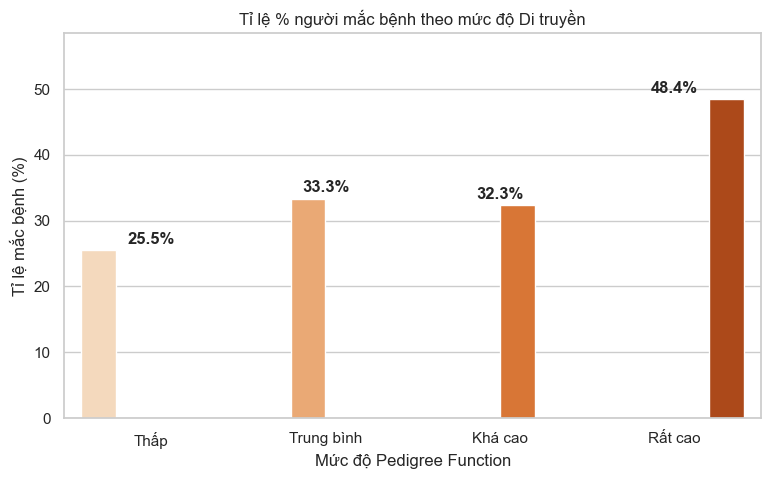

In [46]:
df['pedigree_bins'] = pd.qcut(df['diabetes_pedigree_function'], q=4, labels=['Thấp', 'Trung bình', 'Khá cao', 'Rất cao'])
bin_analysis = df.groupby('pedigree_bins', observed=True)['outcome'].mean() * 100

plt.figure(figsize=(9, 5))
sns.barplot(
    x=bin_analysis.index, 
    y=bin_analysis.values, 
    hue=bin_analysis.index, 
    palette="Oranges", 
    legend=False
)

for i, val in enumerate(bin_analysis.values):
    plt.text(i, val + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.title("Tỉ lệ % người mắc bệnh theo mức độ Di truyền")
plt.ylabel("Tỉ lệ mắc bệnh (%)")
plt.xlabel("Mức độ Pedigree Function")
plt.ylim(0, max(bin_analysis.values) + 10)
plt.show()

> **Nhận xét biểu đồ Tỉ lệ %:**
> *   Biểu đồ cho thấy một xu hướng tăng trưởng tuyến tính rõ rệt: Chỉ số Pedigree càng cao thì tỉ lệ mắc bệnh càng lớn.
> *   Đáng chú ý, nhóm **"Rất cao"** có tỉ lệ mắc bệnh vượt trội, phản ánh rằng yếu tố di truyền là một trong những chỉ báo mạnh mẽ nhất cho căn bệnh tiểu đường trong tập dữ liệu này.

## 3. Phân tích phân phối tích lũy (CDF)
Biểu đồ CDF giúp xác định xác suất tích lũy của chỉ số Pedigree Function cho từng nhóm. Qua đó, chúng ta có thể thấy rõ mức độ "lệch" của nhóm mắc bệnh so với nhóm bình thường ở mọi ngưỡng giá trị.

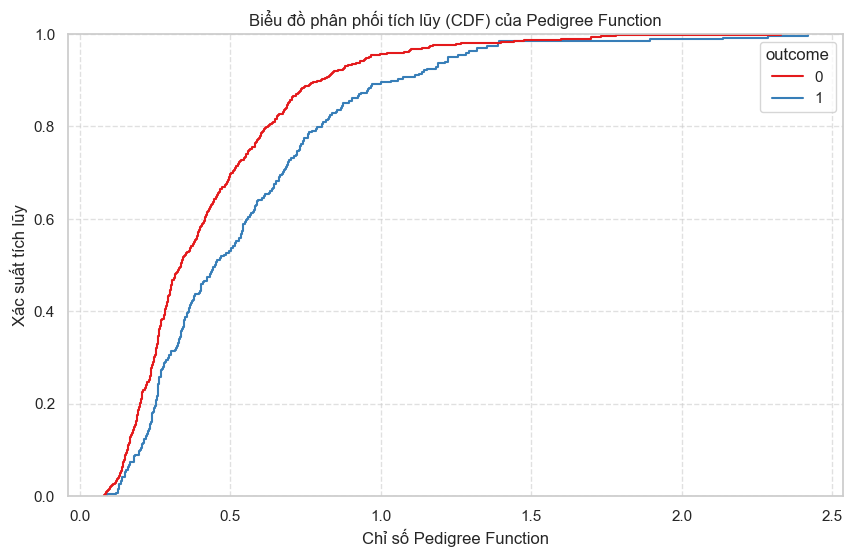

In [47]:
plt.figure(figsize=(10, 6))

# Đường phân phối tích lũy cho cả 2 nhóm
sns.ecdfplot(data=df, x="diabetes_pedigree_function", hue="outcome", palette="Set1")

plt.title("Biểu đồ phân phối tích lũy (CDF) của Pedigree Function")
plt.xlabel("Chỉ số Pedigree Function")
plt.ylabel("Xác suất tích lũy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

> **Nhận xét biểu đồ CDF:**
> * Đường biểu diễn của nhóm **Outcome 0** nằm cao hơn và lệch hẳn về bên trái, cho thấy phần lớn người không bệnh tập trung ở ngưỡng Pedigree thấp.
> * Đường của nhóm **Outcome 1** nằm về bên phải, minh chứng cho việc xác suất xuất hiện các giá trị Pedigree cao ở nhóm này là lớn hơn rất nhiều.

## Kết luận tổng quát 

Dựa trên các biểu đồ đã thực hiện, chúng ta có thể rút ra những nhận xét quan trọng sau:

1.  **Sự phân hóa rõ rệt:** Biểu đồ Violin cho thấy nhóm mắc bệnh (Outcome 1) có mật độ phân phối ở các giá trị Pedigree cao hơn hẳn so với nhóm không mắc bệnh. Trung vị của nhóm 1 nằm ở mức cao hơn đáng kể. 
Đặc biệt, biểu đồ phân phối tích lũy **(CDF)** là bằng chứng toán học mạnh mẽ nhất: đường biểu diễn của nhóm 1 luôn nằm dưới và lệch về bên phải so với nhóm 0. Điều này minh chứng rằng xác suất bắt gặp người có chỉ số di truyền cao ở nhóm mắc bệnh là lớn hơn rõ rệt trên mọi ngưỡng giá trị.

2.  **Tỉ lệ thuận với nguy cơ:** Qua kỹ thuật phân nhóm (Binning), chúng ta thấy một xu hướng tăng dần đều. Người thuộc nhóm có chỉ số di truyền "Rất cao" có tỉ lệ mắc bệnh cao hơn gấp nhiều lần so với nhóm "Thấp".
3.  **Giá trị dự báo:** Chỉ số `diabetes_pedigree_function` là một biến số có giá trị dự báo cực kỳ quan trọng. Kết quả phân tích này cho thấy yếu tố gia đình và di truyền đóng vai trò then chốt trong việc xác định nguy cơ tiểu đường trong tập dữ liệu Pima.